In [11]:
import os.path as osp
import time

import networkx as nx
import torch
import torch.nn.functional as F
from torch.nn import Parameter
from tqdm import tqdm

from torch_geometric.datasets import RelLinkPredDataset
from torch_geometric.nn import GAE, RGCNConv, FastRGCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve

In [12]:
dataset = RelLinkPredDataset('RLPD','FB15k-237')

In [13]:
def graph_to_splitheteroData(data_homo,edgetype,nodetype,val1,val2):
    
    "Converts graph to pyg HeteroData object"

    data_homo.label = torch.tensor(np.array(data_homo.label).astype(int))
    data_homo.node_ids = torch.tensor(list(range(data_homo.num_nodes)))
    data_homo.edge_ids = data_homo.id

    data_homo.edge_ids = torch.tensor(np.array(data_homo.edge_ids).astype(int))

    del data_homo.id

    node_name = data_homo.node_name 

    del data_homo.node_name

    data_homo.edge_types = torch.tensor(np.array(data_homo.relation_type_index.tolist())-val1)
    data_homo.node_type_index = torch.tensor(np.array(data_homo.node_type_index.tolist())-val2) 

    data_hetero = data_homo.to_heterogeneous(node_type = data_homo.node_type_index, 
                      edge_type_names= edgetype, node_type_names = nodetype,edge_type=data_homo.edge_types) 
    #print(data_hetero.edge_types)

    train, valid, test = RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=False, split_labels=False, add_negative_train_samples=False, neg_sampling_ratio=1.0, edge_types=data_hetero.edge_types)(data_hetero)


    train_edge_index = torch.cat((train[data_hetero.edge_types[0]].edge_index,train[data_hetero.edge_types[1]].edge_index),1)
    train_edge_type = torch.cat((train[data_hetero.edge_types[0]].edge_types,train[data_hetero.edge_types[1]].edge_types))
    train_edge_label = torch.cat((train[data_hetero.edge_types[0]].edge_label,train[data_hetero.edge_types[1]].edge_label))
    train_edge_label_index = torch.cat((train[data_hetero.edge_types[0]].edge_label_index,train[data_hetero.edge_types[1]].edge_label_index), 1)
    train_edge_label_type = torch.cat((torch.tensor([0]*train[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*train[data_hetero.edge_types[1]].edge_label_index.shape[1])))

    valid_edge_index = torch.cat((valid[data_hetero.edge_types[0]].edge_index,valid[data_hetero.edge_types[1]].edge_index), 1)
    valid_edge_type = torch.cat((valid[data_hetero.edge_types[0]].edge_types,valid[data_hetero.edge_types[1]].edge_types))
    valid_edge_label = torch.cat((valid[data_hetero.edge_types[0]].edge_label,valid[data_hetero.edge_types[1]].edge_label))
    valid_edge_label_index = torch.cat((valid[data_hetero.edge_types[0]].edge_label_index,valid[data_hetero.edge_types[1]].edge_label_index), 1)
    valid_edge_label_type = torch.cat((torch.tensor([0]*valid[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*valid[data_hetero.edge_types[1]].edge_label_index.shape[1])))

    test_edge_index = torch.cat((test[data_hetero.edge_types[0]].edge_index,test[data_hetero.edge_types[1]].edge_index), 1)
    test_edge_type = torch.cat((test[data_hetero.edge_types[0]].edge_types,test[data_hetero.edge_types[1]].edge_types))
    test_edge_label = torch.cat((test[data_hetero.edge_types[0]].edge_label,test[data_hetero.edge_types[1]].edge_label))
    test_edge_label_index = torch.cat((test[data_hetero.edge_types[0]].edge_label_index,test[data_hetero.edge_types[1]].edge_label_index),1)
    test_edge_label_type =torch.cat((torch.tensor([0]*test[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*test[data_hetero.edge_types[1]].edge_label_index.shape[1])))


    for j in range(2,len(data_hetero.edge_types)):
        train_edge_index = torch.cat((train_edge_index,train[data_hetero.edge_types[j]].edge_index),1)
        train_edge_type = torch.cat((train_edge_type,train[data_hetero.edge_types[j]].edge_types))
        train_edge_label = torch.cat((train_edge_label,train[data_hetero.edge_types[j]].edge_label))
        train_edge_label_index = torch.cat((train_edge_label_index,train[data_hetero.edge_types[j]].edge_label_index), 1)
        train_edge_label_type = torch.cat((train_edge_label_type,torch.tensor([j]*train[data_hetero.edge_types[j]].edge_label_index.shape[1])))

        valid_edge_index = torch.cat((valid_edge_index,valid[data_hetero.edge_types[j]].edge_index), 1)
        valid_edge_type = torch.cat((valid_edge_type,valid[data_hetero.edge_types[j]].edge_types))
        valid_edge_label = torch.cat((valid_edge_label,valid[data_hetero.edge_types[j]].edge_label))
        valid_edge_label_index = torch.cat((valid_edge_label_index,valid[data_hetero.edge_types[j]].edge_label_index), 1)
        valid_edge_label_type = torch.cat((valid_edge_label_type,torch.tensor([j]*valid[data_hetero.edge_types[j]].edge_label_index.shape[1])))

        test_edge_index = torch.cat((test_edge_index,test[data_hetero.edge_types[j]].edge_index), 1)
        test_edge_type = torch.cat((test_edge_type,test[data_hetero.edge_types[j]].edge_types))
        test_edge_label = torch.cat((test_edge_label,test[data_hetero.edge_types[j]].edge_label))
        test_edge_label_index = torch.cat((test_edge_label_index,test[data_hetero.edge_types[j]].edge_label_index),1)
        test_edge_label_type = torch.cat((test_edge_label_type,torch.tensor([j]*test[data_hetero.edge_types[j]].edge_label_index.shape[1])))



    final_data = Data()

    final_data.label = data_homo.label
    final_data.node_ids = data_homo.node_ids 
    final_data.edge_ids = data_homo.edge_ids
    final_data.edge_index = data_homo.edge_index
    final_data.num_nodes = data_homo.num_nodes
    final_data.edge_type = data_homo.edge_types

    #Compiling necessary attributes
    final_data.train_edge_index = train_edge_index
    final_data.train_edge_type = train_edge_type
    final_data.train_edge_label = train_edge_label
    final_data.train_edge_label_index = train_edge_label_index
    final_data.train_edge_label_type = train_edge_label_type

    final_data.valid_edge_index = valid_edge_index
    final_data.valid_edge_type = valid_edge_type
    final_data.valid_edge_label = valid_edge_label
    final_data.valid_edge_label_index = valid_edge_label_index
    final_data.valid_edge_label_type = valid_edge_label_type

    final_data.test_edge_index = test_edge_index
    final_data.test_edge_type = test_edge_type
    final_data.test_edge_label = test_edge_label
    final_data.test_edge_label_index = test_edge_label_index
    final_data.test_edge_label_type = test_edge_label_type

    final_data.num_relations = max(final_data.edge_type.tolist()) + 1

    print(final_data)
    
    return final_data

Relevant data preparation

In [14]:
amr_layerkg = nx.read_gexf(f'n2v_rgcn_kg/rgcn_amr_layerkg.gexf') 

edgetype = [('resistance_gene','arg_drugclass','drug_class'), ('resistance_gene','arg_mechanism', 'resistance_mechanism'), ('resistance_gene','arg_pathogen', 'bacteria'), ('drug_class','drugclass_pathogen','bacteria')]
nodetype = [ 'drug_class', 'resistance_gene', 'bacteria','resistance_mechanism']

data_homo = from_networkx(amr_layerkg)

amr_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,16,6)


Data(label=[1792], node_ids=[1792], edge_ids=[8923], edge_index=[2, 8923], num_nodes=1792, edge_type=[8923], train_edge_index=[2, 7141], train_edge_type=[7141], train_edge_label=[7141], train_edge_label_index=[2, 7141], train_edge_label_type=[7141], valid_edge_index=[2, 7141], valid_edge_type=[7141], valid_edge_label=[1782], valid_edge_label_index=[2, 1782], valid_edge_label_type=[1782], test_edge_index=[2, 8032], test_edge_type=[8032], test_edge_label=[1782], test_edge_label_index=[2, 1782], test_edge_label_type=[1782], num_relations=4)


In [ ]:
whole_kg = nx.read_gexf(f'n2v_rgcn_kg/rgcn_wholekg.gexf') 

edgetype=[('disease', 'disease_disease', 'disease'),('gene/protein', 'protein_protein','gene/protein'),('effect/phenotype', 'phenotype_protein','gene/protein'),
                ('biological_process', 'bioprocess_protein', 'gene/protein'), ('pathway', 'pathway_protein', 'gene/protein'), ('disease','disease_phenotype_positive', 'effect/phenotype'), 
                ('disease', 'disease_protein', 'gene/protein'),  ('disease','disease_immune_phenotype_positive', 'immune_effect/phenotype'), ('effect/phenotype', 'phenotype_phenotype', 'effect/phenotype'),
                ('immune_effect/phenotype', 'immune_phenotype_phenotype', 'effect/phenotype'),  ('immune_effect/phenotype', 'immune_phenotype_immune_phenotype', 'immune_effect/phenotype'), 
                ('immune_effect/phenotype', 'immune_phenotype_protein', 'gene/protein'),  ('drug_class', 'drug_protein', 'gene/protein'), ('bacteria', 'pathogen_disease', 'disease'),
                ('immune_effect/phenotype', 'immune_phenotype_pathogen', 'bacteria'),  ('effect/phenotype', 'phenotype_resistance', 'resistance_gene'),
                ('resistance_gene','arg_drugclass','drug_class'), ('resistance_gene','arg_mechanism', 'resistance_mechanism'), ('resistance_gene','arg_pathogen', 'bacteria'), 
                ('drug_class','drugclass_pathogen','bacteria')]

nodetype = ['disease', 'effect/phenotype','immune_effect/phenotype','biological_process','pathway','gene/protein', 
            'drug_class', 'resistance_gene', 'bacteria','resistance_mechanism']

data_homo = from_networkx(whole_kg)

whole_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,0,0)

Data(label=[13513], node_ids=[13513], edge_ids=[35995], edge_index=[2, 35995], num_nodes=13513, edge_type=[35995], train_edge_index=[2, 28813], train_edge_type=[28813], train_edge_label=[28813], train_edge_label_index=[2, 28813], train_edge_label_type=[28813], valid_edge_index=[2, 28813], valid_edge_type=[28813], valid_edge_label=[7182], valid_edge_label_index=[2, 7182], valid_edge_label_type=[7182], test_edge_index=[2, 32404], test_edge_type=[32404], test_edge_label=[7182], test_edge_label_index=[2, 7182], test_edge_label_type=[7182], num_relations=20)


In [16]:
sub_rgcn = nx.read_gexf(f'n2v_rgcn_kg/subwholekg_rgcn.gexf')


data_homo = from_networkx(sub_rgcn)

#for subgraph, relabelling node_type_index and relation_type_index 
rlti = np.array(data_homo.relation_type_index.tolist())

rlti[rlti == 5] = 3 #disease_ep
rlti[rlti == 6] = 4 #disease_gene
rlti[rlti == 7] = 5 #disease_iep
rlti[rlti == 9] = 6 #iep_ep
rlti[rlti == 11] = 7 #iep_gene

nti = np.array(data_homo.node_type_index.tolist())
nti[nti == 5] = 3 #gene

data_homo.relation_type_index = torch.tensor(rlti)
data_homo.node_type_index = torch.tensor(nti)


edgetype = [('disease', 'disease_disease', 'disease'),('gene/protein', 'protein_protein','gene/protein'),('effect/phenotype', 'phenotype_protein','gene/protein'),
                ('disease','disease_phenotype_positive', 'effect/phenotype'), ('disease', 'disease_protein', 'gene/protein'),  ('disease','disease_immune_phenotype_positive', 'immune_effect/phenotype'),
                ('immune_effect/phenotype', 'immune_phenotype_phenotype', 'effect/phenotype'), ('immune_effect/phenotype', 'immune_phenotype_protein', 'gene/protein')]

nodetype = ['disease', 'effect/phenotype','immune_effect/phenotype','gene/protein']

sub_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,0,0)

Data(label=[360], node_ids=[360], edge_ids=[1196], edge_index=[2, 1196], num_nodes=360, edge_type=[1196], train_edge_index=[2, 962], train_edge_type=[962], train_edge_label=[962], train_edge_label_index=[2, 962], train_edge_label_type=[962], valid_edge_index=[2, 962], valid_edge_type=[962], valid_edge_label=[234], valid_edge_label_index=[2, 234], valid_edge_label_type=[234], test_edge_index=[2, 1079], test_edge_type=[1079], test_edge_label=[234], test_edge_label_index=[2, 234], test_edge_label_type=[234], num_relations=8)


In [23]:
#for link prediction as created in n2v_pyg_specific_graph_creation.ipynb
ep_arg = np.loadtxt(f'n2v_rgcn_kg/lp_ep_arg.csv') 

iep_bact = np.loadtxt(f'n2v_rgcn_kg/lp_iep_bact.csv')

iep_gene = np.loadtxt(f'n2v_rgcn_kg/lp_iep_gene.csv') 

dis_iep = np.loadtxt(f'n2v_rgcn_kg/lp_dis_iep.csv') 



In [24]:
ep_arg = torch.tensor(ep_arg.astype(int))

ep_arg_edge_type = torch.tensor([15]*ep_arg.shape[1])

In [25]:
iep_bact = torch.tensor(iep_bact.astype(int))

iep_bact_edge_type = torch.tensor([14]*iep_bact.shape[1])

In [26]:
iep_gene = torch.tensor(iep_gene.astype(int))

iep_gene_edge_type = torch.tensor([11]*iep_gene.shape[1])

In [27]:
dis_iep = torch.tensor(dis_iep.astype(int))

dis_iep_edge_type = torch.tensor([7]*dis_iep.shape[1])

In [ ]:
#for_link_pred_data = torch.cat((ep_arg,iep_bact,iep_gene,dis_iep), 1)
#for_link_pred_data_edge_type = torch.cat((ep_arg_edge_type,iep_bact_edge_type,iep_gene_edge_type,dis_iep_edge_type))

Change below depending on what data you want to use (between amr layer, whole kg, 1-hop subgraph of whole kg). 

In [29]:
data = whole_data

   R-GCN implementation 

In [30]:
""""
Implements the link prediction task on the FB15k237 datasets according to the
`"Modeling Relational Data with Graph Convolutional Networks"
<https://arxiv.org/abs/1703.06103>`_ paper.

Caution: This script is executed in a full-batch fashion, and therefore needs
to run on CPU (following the experimental setup in the official paper).

Source: Pytorch Geometric Github.

Only major change made is with respect to metrics, removed MRR functions and created AUC/AP functions (MAB)
"""

'"\nImplements the link prediction task on the FB15k237 datasets according to the\n`"Modeling Relational Data with Graph Convolutional Networks"\n<https://arxiv.org/abs/1703.06103>`_ paper.\n\nCaution: This script is executed in a full-batch fashion, and therefore needs\nto run on CPU (following the experimental setup in the official paper).\n\nSource: Pytorch Geometric Github.\n\nOnly major change made is with respect to metrics, removed MRR functions and created AUC/AP functions (MAB)\n'

In [31]:
class RGCNEncoder(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels, num_relations):
        super().__init__()
        self.node_emb = Parameter(torch.empty(num_nodes, hidden_channels))
        self.conv1 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                              num_blocks=5)
        self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                              num_blocks=5)
        self.conv3 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                                      num_blocks=5)
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.xavier_uniform_(self.node_emb)
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()
        self.conv3.reset_parameters()

    def forward(self, edge_index, edge_type):
        x = self.node_emb
        x = self.conv1(x, edge_index, edge_type).relu_()
        x = F.dropout(x, p=0.2, training=self.training) 
        x = self.conv2(x, edge_index, edge_type)#.relu()
        #x = F.dropout(x,p=0.1, training=self.training)
        #x = self.conv3(x,edge_index,edge_type)
        
        return x


class DistMultDecoder(torch.nn.Module):
    def __init__(self, num_relations, hidden_channels):
        super().__init__()
        self.rel_emb = Parameter(torch.empty(num_relations, hidden_channels))
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.xavier_uniform_(self.rel_emb)

    def forward(self, z, edge_index, edge_type):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        rel = self.rel_emb[edge_type]
        return torch.sum(z_src * rel * z_dst, dim=1)

In [32]:
model = GAE(
    RGCNEncoder(data.num_nodes, 200, data.num_relations),
    DistMultDecoder(data.num_relations, 200),
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


def negative_sampling(edge_index, num_nodes):
    # Sample edges by corrupting either the subject or the object of each edge.
    mask_1 = torch.rand(edge_index.size(1)) < 0.5
    mask_2 = ~mask_1

    neg_edge_index = edge_index.clone()
    neg_edge_index[0, mask_1] = torch.randint(num_nodes, (mask_1.sum(), ),
                                              device=neg_edge_index.device)
    neg_edge_index[1, mask_2] = torch.randint(num_nodes, (mask_2.sum(), ),
                                              device=neg_edge_index.device)
    return neg_edge_index


In [33]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(data.edge_index, data.edge_type)

    pos_out = model.decode(z, data.train_edge_index, data.train_edge_type)

    neg_edge_index = negative_sampling(data.train_edge_index, data.num_nodes)
    neg_out = model.decode(z, neg_edge_index, data.train_edge_type)

    out = torch.cat([pos_out, neg_out])
    gt = torch.cat([torch.ones_like(pos_out), torch.zeros_like(neg_out)])
    cross_entropy_loss = F.binary_cross_entropy_with_logits(out, gt)
    reg_loss = z.pow(2).mean() + model.decoder.rel_emb.pow(2).mean()
    loss = cross_entropy_loss + 1e-2 * reg_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
    optimizer.step()

    return float(loss)

In [34]:
@torch.no_grad()
def valid():
    model.eval()
    z = model.encode(data.edge_index, data.edge_type)

    v_auc_score,v_ap_score, v_fpr, v_tpr, v_precision, r_recall = compute_auc_roc_ap(z, data.valid_edge_label_index, data.valid_edge_label_type.int(), data.valid_edge_label)
    
    return v_auc_score,v_ap_score, v_fpr, v_tpr , v_precision, r_recall


In [35]:
@torch.no_grad()
def test():
    model.eval()
    z = model.encode(data.edge_index, data.edge_type)

    test_auc_score,test_ap_score, t_fpr, t_tpr, t_precision, t_recall = compute_auc_roc_ap(z, data.test_edge_label_index, data.test_edge_label_type.int(), data.test_edge_label)

    return test_auc_score,test_ap_score, t_fpr, t_tpr, t_precision, t_recall

In [36]:
def compute_auc_roc_ap(z, eval_edge_index, eval_edge_type, true_labels):
    out = model.decode(z, eval_edge_index, eval_edge_type)

    auc_score = roc_auc_score(true_labels, out)
    ap_score = average_precision_score(true_labels,out)
    fpr, tpr, _ = roc_curve(true_labels, out)

    precision, recall, _= precision_recall_curve(true_labels, out)

    return auc_score,ap_score, fpr, tpr, precision, recall

In [37]:
def metric_plots(auc_score,ap_score, fpr, tpr, precision, recall):

    print(f'AUC: {auc_score}')
    print(f'AP: {ap_score}')
    print(f'\n')
 
    
    plt.plot(fpr, tpr,'orange', label = f'AUC={"%.3f"%auc_score}')
    plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
    plt.xlabel('False postive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC')

    return 

In [38]:
times = []
for epoch in range(1, 401):
    start = time.time()
    loss = train()
    print(f'Epoch: {epoch:05d}, Loss: {loss:.4f}')
    if (epoch % 10) == 0:
        v_auc_score,v_ap_score, _ , _ , _,_= valid()
        print(f'Valid AUC: {v_auc_score:.4f}, Valid AP: {v_ap_score:.4f}')
    times.append(time.time() - start)
print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

/tmp/ipykernel_207203/1753560910.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  return float(loss)


Epoch: 00001, Loss: 0.6932
Epoch: 00002, Loss: 0.6924
Epoch: 00003, Loss: 0.6832
Epoch: 00004, Loss: 0.6485
Epoch: 00005, Loss: 0.6212
Epoch: 00006, Loss: 0.5499
Epoch: 00007, Loss: 0.5222
Epoch: 00008, Loss: 0.4475
Epoch: 00009, Loss: 0.4121
Epoch: 00010, Loss: 0.3747
Valid AUC: 0.6632, Valid AP: 0.6007
Epoch: 00011, Loss: 0.3511
Epoch: 00012, Loss: 0.3092
Epoch: 00013, Loss: 0.2950
Epoch: 00014, Loss: 0.2907
Epoch: 00015, Loss: 0.2735
Epoch: 00016, Loss: 0.2625
Epoch: 00017, Loss: 0.2514
Epoch: 00018, Loss: 0.2558
Epoch: 00019, Loss: 0.2517
Epoch: 00020, Loss: 0.2412
Valid AUC: 0.8069, Valid AP: 0.7493
Epoch: 00021, Loss: 0.2368
Epoch: 00022, Loss: 0.2288
Epoch: 00023, Loss: 0.2280
Epoch: 00024, Loss: 0.2175
Epoch: 00025, Loss: 0.2169
Epoch: 00026, Loss: 0.2107
Epoch: 00027, Loss: 0.2057
Epoch: 00028, Loss: 0.2052
Epoch: 00029, Loss: 0.2053
Epoch: 00030, Loss: 0.2010
Valid AUC: 0.7911, Valid AP: 0.7105
Epoch: 00031, Loss: 0.1983
Epoch: 00032, Loss: 0.2030
Epoch: 00033, Loss: 0.1962
E

In [39]:
#Testing
test_auc_score,test_ap_score, t_fpr, t_tpr, precision, recall = test()


AUC: 0.8089158739542006
AP: 0.7751713073490132




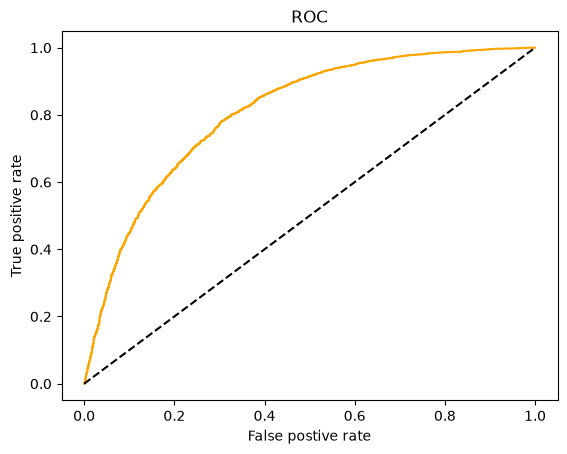

In [40]:
metric_plots(test_auc_score,test_ap_score, t_fpr, t_tpr, precision, recall)

In [41]:
#np.savetxt(f'n2v_rgcn_kg/rgcn_fpr.csv',t_fpr)
#np.savetxt(f'n2v_rgcn_kg/rgcn_tpr.csv',t_tpr)

#np.savetxt(f'n2v_rgcn_kg/rgcn_precision.csv',precision)
#np.savetxt(f'n2v_rgcn_kg/rgcn_recall.csv',recall)

Main prediction experiment

In [ ]:
z = model.encode(data.edge_index, data.edge_type)
out1 = model.decode(z, ep_arg, ep_arg_edge_type)

In [ ]:
z = model.encode(data.edge_index, data.edge_type)
out2 = model.decode(z, iep_bact, iep_bact_edge_type)

In [ ]:
z = model.encode(data.edge_index, data.edge_type)
out3 = model.decode(z, iep_gene, iep_gene_edge_type)

In [ ]:
z = model.encode(data.edge_index, data.edge_type)
out4 = model.decode(z, dis_iep, dis_iep_edge_type)

In [ ]:
out1

tensor([-3.5913, -6.8317, -4.2241,  ..., -3.8235, -4.4622, -5.2499],
       grad_fn=<SumBackward1>)

In [ ]:
node_list = np.loadtxt('node_list.csv')


def get_node_names(id1,id2):
    node_1 = node_list[id1]
    node_2 = node_list[id2]

    node_1 = whole_kg.nodes[node_1]
    node_2 = whole_kg.nodes[node_2]

    return (node_1,node_2)


In [ ]:
torch.sort(out1,descending=True).values[0:11]

tensor([ 7.6902,  1.8678,  1.4089,  1.0724,  0.8145,  0.6552,  0.5602,  0.5186,
         0.2116, -0.0188, -0.0614], grad_fn=<SliceBackward0>)

In [ ]:
torch.sort(out1,descending=True).indices[0:11].tolist()

[165260,
 564396,
 214826,
 394825,
 502661,
 594709,
 171691,
 402880,
 176072,
 387088,
 572075]

In [ ]:
ep_arg[0][torch.sort(out1,descending=True).indices[0:11].tolist()]

tensor([5983,   29,   42, 4465,  471,  102,  471, 5333, 3442,  522, 1369])

In [ ]:
ep_arg[1][torch.sort(out1,descending=True).indices[0:11].tolist()]

tensor([  41, 5985, 3499,   29, 6112, 5278, 6110,   43,   38, 6634, 5983])